# Pairs trading on the day lake — III. Twenty years, three selection rules

## `pairs_trading_09_daily_portfolio.ipynb`

Notebook 07 built a point-in-time universe and fixed the price basis; notebook 08 screened it and found
that the evidence for cointegration among liquid US equities is thin and concentrated. This notebook
trades the result properly and asks what it was worth.

The design is the classical formation/trading split, rolled: at each of 39 semi-annual formation dates,
select pairs on the trailing two years, trade them for the next six months, then re-select. Nothing in a
trading window informs its own selection, hedge or z-score. Three selection rules compete:

| rule | pairs per formation | basis |
|---|---|---|
| **BH dual-gate** | up to 20, smallest corrected $p$ | the notebook-07 screen with FDR control |
| **raw-$p$ dual-gate** | up to 20, smallest raw $p$ | the same screen with the correction switched off — what notebook 03 does as an ablation |
| **distance** | 20 | Gatev et al. (2006): smallest sum of squared deviations, no test at all |

On top of that: a cost sweep, a dividend accounting check, a decomposition by regime, and the experiment
that matters most for reading notebooks 01–05 — the same backtest run on today's index members instead
of the point-in-time universe.

Thirty-nine folds spanning 2006–2025 give roughly 4,900 trading days, so an annualised Sharpe carries a
standard error near 0.23. For the first time in this repository the sample is large enough to separate a
small edge from nothing.

**Caching.** The backtest is a few minutes; notebook 08's screen caches are required and rebuilt if
missing (about an hour).

## 0. Setup

In [1]:
from pathlib import Path
import os, sys, time, re, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

import pairs
from pairs import (load_universe, load_daily_bars, liquidity_screen, generate_pair_signals,
                   evaluate_pair_signals, estimate_halflife, estimate_halflife_window,
                   fit_kalman_hedge, filter_kf_on_new, plot_pair_legs_with_trades)
from pairs.models.kalman import _kalman_dynamic_hedge

LAKE        = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET_ROOT = LAKE / "all_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, END = "2004-01-01", "2025-08-13"
FORM_YEARS, MIN_PRICE, MIN_DV, MIN_VOL, MAX_ABS_RET, TOP_N = 2, 5.0, 20e6, 0.15, 1.0, 300
MAX_PAIRS, CAP, COST_BPS, BORROW_BPS = 20, 10_000, 5.0, 50
Z_ENTRY, Z_EXIT, Z_STOP = 2.0, 0.5, 4.0
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
print("pairs", pairs.__version__)

pairs 0.1.0


## 1. Data, universe and the selections

The bars, the point-in-time universe and the three rule files all come from notebooks 07 and 08.

In [2]:
f_bars = CACHE / "day_market_bars.parquet"
if not f_bars.exists():
    load_daily_bars(None, START, END, MARKET_ROOT, with_dividends=True).to_parquet(f_bars)
bars = pd.read_parquet(f_bars)
sessions = pd.DatetimeIndex(sorted(bars.index.get_level_values("datetime").unique()))
TEST_SYMBOLS = sorted(t for t in bars.index.get_level_values("ticker").unique()
                      if re.fullmatch(r"Z[A-Z]ZZT", str(t)))

PX  = bars["close"].unstack("ticker")
DIV = bars["dividend"].unstack("ticker").reindex_like(PX).fillna(0.0)

def formation_dates(first="2006-06-30", freq="6MS"):
    anchors = pd.date_range(first, sessions[-1], freq=freq)
    return pd.DatetimeIndex(sorted({sessions[sessions <= a][-1] for a in anchors if (sessions <= a).any()}))

FORMATIONS = formation_dates()
WINDOWS = {d: (d, nxt) for d, nxt in zip(FORMATIONS, list(FORMATIONS[1:]) + [sessions[-1]])}

RULES = {}
for name in ("bh_dual", "raw_dual_top20", "distance_top20"):
    f = CACHE / f"day_rule_{name}.parquet"
    if not f.exists():
        raise FileNotFoundError(f"{f} is missing — run notebooks/pairs_trading_08_daily_cointegration.ipynb first")
    RULES[name] = pd.read_parquet(f)
order_col = {"bh_dual": "eg_p_fdr", "raw_dual_top20": "eg_p", "distance_top20": "ssd"}

def selections(rule, formation, limit=MAX_PAIRS):
    df = RULES[rule]
    g = df[df["formation"] == formation].nsmallest(limit, order_col[rule])
    return list(zip(g["ticker1"], g["ticker2"]))

counts = pd.DataFrame({r: {d: len(selections(r, d)) for d in FORMATIONS} for r in RULES})
print(f"{len(FORMATIONS)} formations {FORMATIONS[0].date()} → {FORMATIONS[-1].date()}; "
      f"holding windows of {int(np.median([len(sessions[(sessions > a) & (sessions <= b)]) for a, b in WINDOWS.values()]))} sessions")
display(counts.describe().loc[["mean", "min", "max"]].round(1))

39 formations 2006-06-30 → 2025-07-01; holding windows of 126 sessions


,bh_dual,raw_dual_top20,distance_top20
mean,7.4,20.0,20.0
min,0.0,20.0,20.0
max,20.0,20.0,20.0


## 2. The engine

For one pair and one fold:

1. **Hedge.** Ordinary least squares of $P_1$ on $P_2$ over the formation window, frozen for the trading
   window. Notebook 12 found on minute bars that a hedge which re-estimates faster than the spread
   reverts destroys the signal; the daily equivalent of that caution is a hedge fixed per fold. A Kalman
   alternative is compared in §4.
2. **Signal.** Robust z-score of the residual, look-back $3\times$ its half-life over the formation
   window (clipped to 20–250 sessions) and warmed up on it, so the trading window never informs its own
   z-score. Entry at $|z|\ge2$ while below the stop, exit at $|z|\le0.5$, stop at $|z|\ge4$, next-day
   execution, \$10,000 dollar-neutral.
3. **Costs.** 5 bps per leg per side, 50 bp/year borrow on the short leg, and dividends accrued on the
   ex-date: long legs receive them, short legs pay them.

Each pair-fold is run independently and starts flat, so a spread still wide at a re-formation is closed
and reopened rather than held across the boundary. (Notebook 12 stitches folds on minute bars; this one
does not, which if anything understates the rule by charging a round-trip it need not pay.)

In [3]:
def ols(y, x):
    X = np.column_stack([np.ones(len(x)), x])
    (a, b), *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(a), float(b)

def fold_frames(pair, formation):
    a, b = pair
    if a not in PX.columns or b not in PX.columns:
        return None, None
    start = formation - pd.DateOffset(years=FORM_YEARS)
    lo, hi = WINDOWS[formation]
    form = pd.DataFrame({"P1": PX[a], "P2": PX[b]}).loc[(PX.index > start) & (PX.index <= formation)].dropna()
    trade = pd.DataFrame({"P1": PX[a], "P2": PX[b], "D1": DIV[a], "D2": DIV[b]}).loc[
        (PX.index > lo) & (PX.index <= hi)].dropna()
    if len(form) < 250 or len(trade) < 20:
        return None, None
    return form, trade

def run_pair(pair, formation, hedge="static", cost_bps=COST_BPS, carry=None, with_dividends=True):
    form, trade = fold_frames(pair, formation)
    if form is None:
        return None
    if hedge == "static":
        alpha, beta = ols(form["P1"].to_numpy(), form["P2"].to_numpy())
        resid_form = form["P1"] - alpha - beta * form["P2"]
        states = trade[["P1", "P2"]].assign(beta=beta, resid=trade["P1"] - alpha - beta * trade["P2"])
    else:
        _, _, st, params = _kalman_dynamic_hedge("P1", "P2", form, q=1e-5, em_iters=5, mode="filter",
                                                 return_params=True)
        if st is None:
            return None
        resid_form = st["resid"]
        frozen = {k: params[k] for k in ("F", "Q", "R")}
        st_te, _ = filter_kf_on_new(trade["P1"], trade["P2"], frozen=frozen,
                                    last_state=(params["last_state_mean"], params["last_state_cov"]),
                                    mode="filter")
        states = trade[["P1", "P2"]].join(st_te[["beta", "resid"]], how="inner")
        if states.empty:
            return None
    win = int(np.clip(3 * estimate_halflife(resid_form.dropna()), 20, 250)) if np.isfinite(
        estimate_halflife(resid_form.dropna())) else 60
    sig = generate_pair_signals(states, z_method="robust", z_window=win, z_history=resid_form.dropna(),
                                z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP, capital_per_pair=CAP,
                                initial_position=carry)
    daily, trades, summ = evaluate_pair_signals(states[["P1", "P2"]], sig, cost_bps=cost_bps,
                                                borrow_bps_per_year=BORROW_BPS, days_per_year=252,
                                                bars_per_year=252, capital_base=CAP)
    div_pnl = pd.Series(0.0, index=daily.index)
    if with_dividends:
        d = trade.loc[daily.index]
        div_pnl = sig["n1"] * d["D1"] + sig["n2"] * d["D2"]
    out = pd.DataFrame({"pnl": daily["pnl_net"] + div_pnl, "pnl_ex_div": daily["pnl_net"],
                        "dividends": div_pnl, "cost": daily["cost"]})
    end = (int(sig["pos"].iloc[-1]), float(sig["n1"].iloc[-1]), float(sig["n2"].iloc[-1]))
    return {"pair": pair, "formation": formation, "frame": out, "n_trades": int(len(trades)), "end": end,
            "z_window": win}

def backtest(rule, hedge="static", cost_bps=COST_BPS, universe_filter=None, with_dividends=True,
             limit=MAX_PAIRS, n_jobs=-1):
    jobs = []
    for d in FORMATIONS:
        for p in selections(rule, d, limit):
            if universe_filter is not None and not universe_filter(p, d):
                continue
            jobs.append((p, d))
    res = Parallel(n_jobs=n_jobs)(
        delayed(run_pair)(p, d, hedge, cost_bps, None, with_dividends) for p, d in jobs)
    res = [r for r in res if r is not None]
    if not res:
        return None
    pnl = pd.DataFrame(0.0, index=sessions, columns=["pnl", "pnl_ex_div", "dividends", "cost"])
    active = pd.Series(0, index=sessions, dtype=int)
    for r in res:
        pnl.loc[r["frame"].index] += r["frame"].reindex(pnl.index).fillna(0.0).loc[r["frame"].index]
        active.loc[r["frame"].index] += 1
    live = active > 0
    pnl, active = pnl[live], active[live]
    ret = pnl["pnl"] / (active * CAP)                       # return on capital actually deployed
    sharpe = float(ret.mean() / ret.std(ddof=0) * np.sqrt(252)) if ret.std(ddof=0) > 0 else np.nan
    equity = pnl["pnl"].cumsum()
    return {"rule": rule, "hedge": hedge, "pnl": pnl, "active": active, "ret": ret, "equity": equity,
            "sharpe": sharpe, "sharpe_se": float(np.sqrt(252 / len(ret))), "results": res,
            "n_pairs": len(res), "n_trades": int(sum(r["n_trades"] for r in res)),
            "total_pnl": float(pnl["pnl"].sum()), "dividends": float(pnl["dividends"].sum()),
            "costs": float(pnl["cost"].sum()), "avg_active": float(active.mean()),
            "max_dd": float((equity - equity.cummax()).min()),
            "ann_return_on_capital": float(ret.mean() * 252)}

def row(r):
    return {"": f"{r['rule']} / {r['hedge']}", "Sharpe": r["sharpe"], "± s.e.": r["sharpe_se"],
            "return on capital": r["ann_return_on_capital"], "P&L ($k)": r["total_pnl"] / 1e3,
            "costs ($k)": r["costs"] / 1e3, "dividends ($k)": r["dividends"] / 1e3,
            "max DD ($k)": r["max_dd"] / 1e3, "pair-folds": r["n_pairs"], "trades": r["n_trades"],
            "avg pairs live": r["avg_active"]}

## 3. The three selection rules

Each rule is run over the full twenty years with the same hedge, signal and costs. The only difference is
which pairs it picks.

three backtests in 20s


,Sharpe,± s.e.,return on capital,P&L ($k),costs ($k),dividends ($k),max DD ($k),pair-folds,trades,avg pairs live
,,,,,,,,,,
bh_dual / static,0.402,0.262,0.022,43.587,8.495,0.483,-11.082,287,723,9.619
raw_dual_top20 / static,0.040,0.229,0.002,5.650,24.315,2.156,-38.583,779,2066,19.937
distance_top20 / static,-0.412,0.229,-0.003,-12.563,19.568,-1.440,-15.720,780,1594,19.969


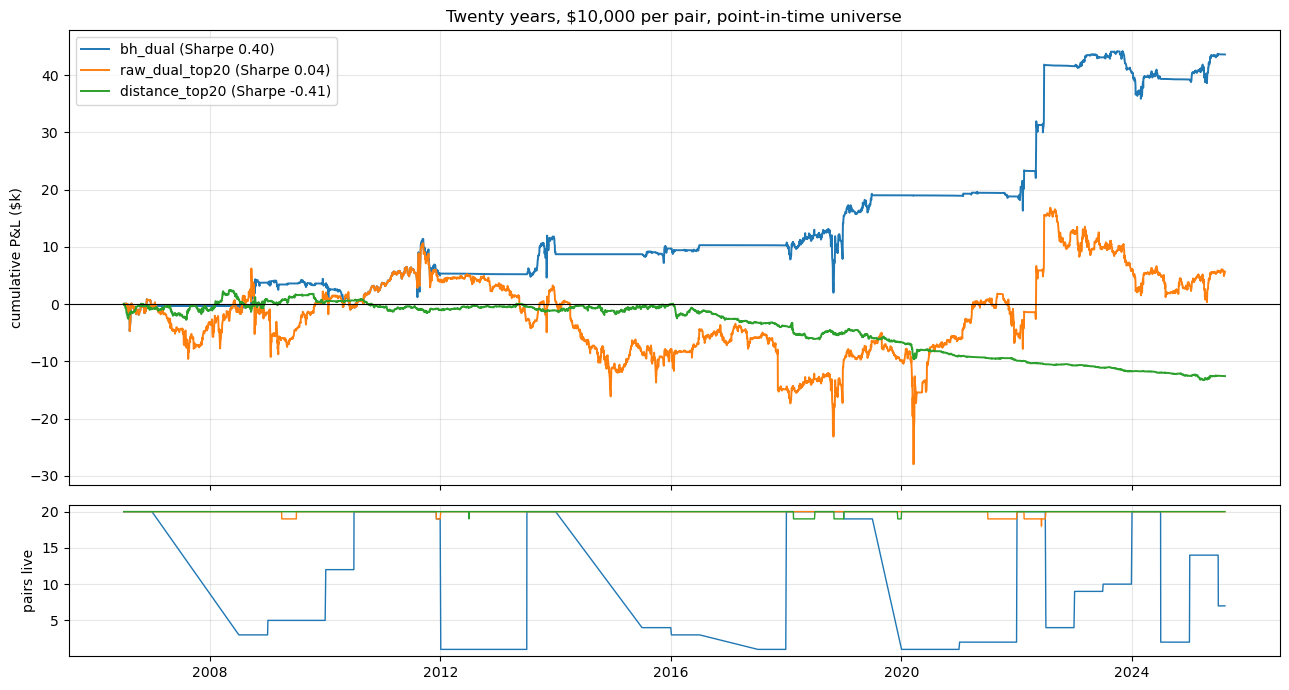

In [4]:
t0 = time.time()
runs = {name: backtest(name) for name in RULES}
print(f"three backtests in {time.time() - t0:.0f}s")
table = pd.DataFrame([row(r) for r in runs.values()]).set_index("")
display(table.round(3))

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True, height_ratios=[3, 1])
for name, r in runs.items():
    ax[0].plot(r["equity"].index, r["equity"] / 1e3, lw=1.4, label=f"{name} (Sharpe {r['sharpe']:.2f})")
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_ylabel("cumulative P&L ($k)")
ax[0].set_title("Twenty years, $10,000 per pair, point-in-time universe"); ax[0].legend()
for name, r in runs.items():
    ax[1].plot(r["active"].index, r["active"], lw=1)
ax[1].set_ylabel("pairs live"); plt.tight_layout(); plt.show()

The ordering is the result, and it is the one the statistics predicted.

| rule | Sharpe | return on deployed capital | twenty-year P&L |
|---|---|---|---|
| BH dual-gate | **+0.40** ± 0.26 | +2.2% | +\$43.6k |
| raw-$p$ dual-gate | +0.04 ± 0.23 | +0.2% | +\$5.7k |
| distance | −0.41 ± 0.23 | −0.3% | −\$12.6k |

Multiple-testing control earns its keep. The rule that survives FDR correction is the only one that makes
money; dropping the correction and taking the twenty smallest raw $p$-values gives a portfolio that trades
nearly three times as often, pays three times the costs and returns nothing; and the distance method,
which selects on co-movement without any test, loses. Notebook 03 built the raw-$p$ ablation on a single
pair over five years and could not tell the difference. Over twenty years and 780 pair-folds it is
visible.

Two things temper it. The BH result is **1.5 standard errors from zero** — suggestive, not significant,
and this is the largest sample this repository can build. And the rule trades only when the screen finds
something: 287 pair-folds against 780, with fewer than ten pairs live on average, which caps the whole
book at roughly \$100k of deployed capital.

## 3.5 One pair, one fold — what the rule is actually trading

The tables above are portfolio aggregates over 287 pair-folds. They say nothing about what a single
position looks like, which is the view notebooks 01–03 give and the one worth having before trusting any
of it. This section opens the engine on one pair-fold and shows the same four things those notebooks do:
the trades on each leg, the z-score that produced them, the equity curve, and the performance summary.

In [5]:
# run_pair() keeps only the aggregated P&L frame; this mirrors it exactly but returns the internals
def run_pair_detail(pair, formation, hedge="static", cost_bps=COST_BPS):
    form, trade = fold_frames(pair, formation)
    alpha, beta = ols(form["P1"].to_numpy(), form["P2"].to_numpy())
    resid_form  = form["P1"] - alpha - beta * form["P2"]
    states = trade[["P1", "P2"]].assign(beta=beta, resid=trade["P1"] - alpha - beta * trade["P2"])
    hl = estimate_halflife(resid_form.dropna())
    win = int(np.clip(3 * hl, 20, 250)) if np.isfinite(hl) else 60
    sig = generate_pair_signals(states, z_method="robust", z_window=win, z_history=resid_form.dropna(),
                                z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP, capital_per_pair=CAP)
    daily, trades, summ = evaluate_pair_signals(states[["P1", "P2"]], sig, cost_bps=cost_bps,
                                                borrow_bps_per_year=BORROW_BPS, days_per_year=252,
                                                bars_per_year=252, capital_base=CAP)
    return states, sig, daily, trades, summ, dict(alpha=alpha, beta=beta, halflife=hl, z_window=win)

# rank the best rule's pair-folds by what they contributed, and take the largest
best_rule = max(runs, key=lambda k: runs[k]["sharpe"])
contrib = sorted(runs[best_rule]["results"], key=lambda d: float(d["frame"]["pnl"].sum()), reverse=True)
top = pd.DataFrame([{"pair": f"{d['pair'][0]}/{d['pair'][1]}", "formation": d["formation"].date(),
                     "P&L ($)": float(d["frame"]["pnl"].sum()), "trades": d["n_trades"]}
                    for d in contrib[:8]]).set_index("pair")
print(f"largest contributors among the {len(contrib)} {best_rule} pair-folds:")
display(top.round(1))

# the names at the top of that list are worth a second look
LEVERAGED = set((
    "TVIX UVXY VXX VIXY SVXY UVIX SVIX TQQQ SQQQ FAS FAZ LABU LABD DUST NUGT JNUG JDST "
    "SOXL SOXS SPXL SPXS SPXU UPRO SDOW UDOW TZA TNA YINN YANG ERX ERY GUSH DRIP BOIL "
    "KOLD UCO SCO AGQ ZSL TMF TMV TECL TECS CURE DRN DRV RETL WEBL WEBS NAIL FNGU FNGD "
    "BNKU UWM TWM QLD QID SSO SDS DDM DXD SAA UYG SKF UYM SMN URE SRS DIG DUG UGL GLL"
).split())
is_lev = lambda pr: pr[0] in LEVERAGED or pr[1] in LEVERAGED
lev  = [d for d in contrib if is_lev(d["pair"])]
tot  = sum(float(d["frame"]["pnl"].sum()) for d in contrib)
levp = sum(float(d["frame"]["pnl"].sum()) for d in lev)
print(f"\npair-folds involving a leveraged / inverse / volatility product: "
      f"{len(lev)} of {len(contrib)} ({len(lev)/len(contrib):.1%})")
print(f"  their share of the rule's total P&L: ${levp:,.0f} of ${tot:,.0f} ({levp/tot:.1%})")
print(f"  distinct such tickers selected: "
      f"{sorted({t for d in lev for t in d['pair']} & LEVERAGED)}")

PICK = contrib[0]
states, sig, daily, trades, summ, fit = run_pair_detail(PICK["pair"], PICK["formation"])
t1, t2 = PICK["pair"]
print(f"\nshowing {t1}/{t2}, formation {PICK['formation'].date()}, "
      f"trading {states.index[0].date()} -> {states.index[-1].date()}  "
      f"({len(states)} sessions)")
print(f"hedge: P1 = {fit['alpha']:.2f} + {fit['beta']:.4f} x P2  |  "
      f"residual half-life {fit['halflife']:.1f} sessions -> z look-back {fit['z_window']}")

largest contributors among the 287 bh_dual pair-folds:


,formation,P&L ($),trades
pair,,,
BAC/CNX,2008-07-01,4140.2,4
TVIX/VRTX,2018-06-29,2808.4,3
FAZ/PBR.A,2011-07-01,2775.3,1
FAZ/SPLS,2011-07-01,2761.2,1
RYL/URBN,2006-06-30,2100.8,7
LABU/PLUG,2023-12-29,1969.5,1
UVXY/VRTX,2018-06-29,1827.5,2
DUST/HST,2017-12-29,1773.6,4



pair-folds involving a leveraged / inverse / volatility product: 112 of 287 (39.0%)
  their share of the rule's total P&L: $16,854 of $43,587 (38.7%)
  distinct such tickers selected: ['DIG', 'DUST', 'FAS', 'FAZ', 'LABU', 'QID', 'SKF', 'SOXS', 'SPXU', 'SQQQ', 'TMF', 'TVIX', 'TZA', 'UPRO', 'UVXY', 'UYG', 'VXX']

showing BAC/CNX, formation 2008-07-01, trading 2008-07-02 -> 2008-12-31  (127 sessions)
hedge: P1 = 63.66 + -0.3149 x P2  |  residual half-life 6.3 sessions -> z look-back 20


(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • BAC (top), CNX (bottom)'}, ylabel='Price'>))

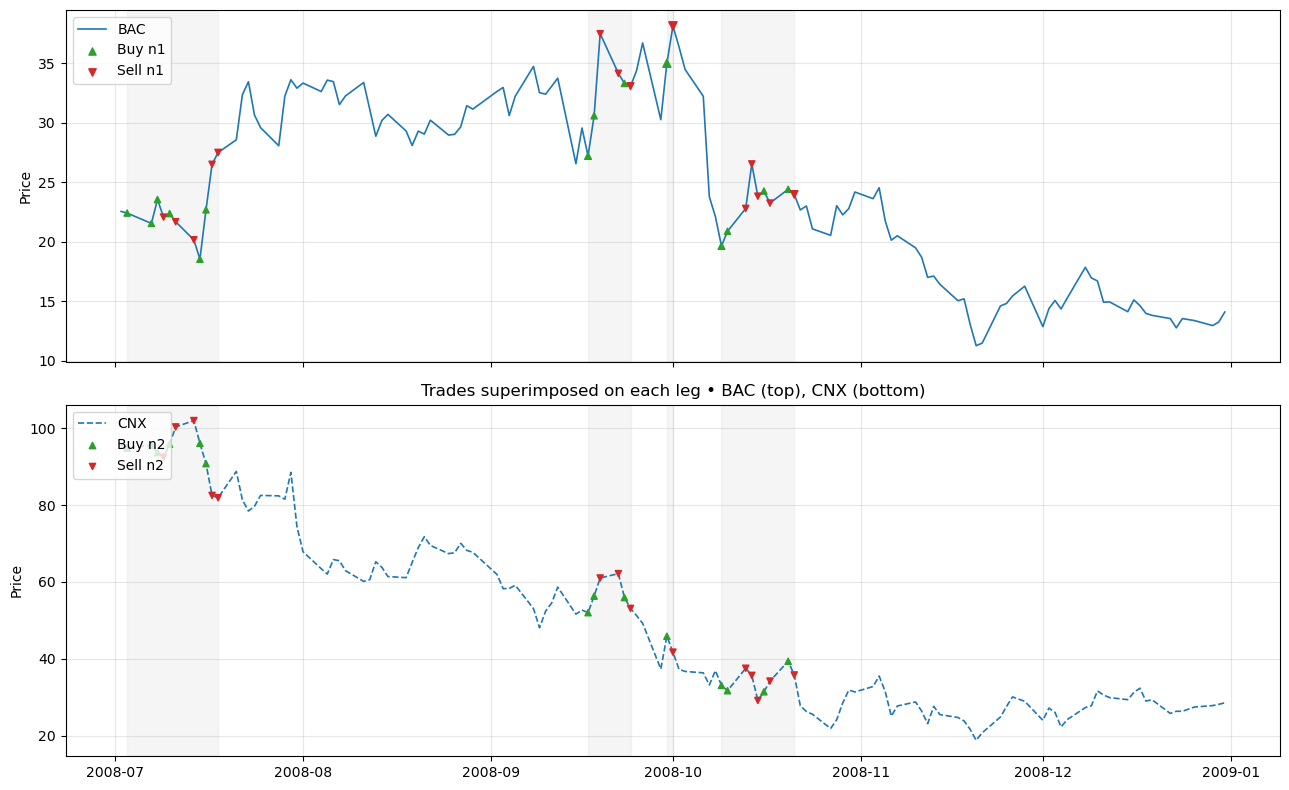

In [6]:
# 1) trades on each leg -- the same view as notebook 02 section 4.3
plot_pair_legs_with_trades(states[["P1", "P2"]], sig, label1=t1, label2=t2,
                           normalize=False, shade_positions=True,
                           size_scale=0.004, min_marker=20, max_marker=220)

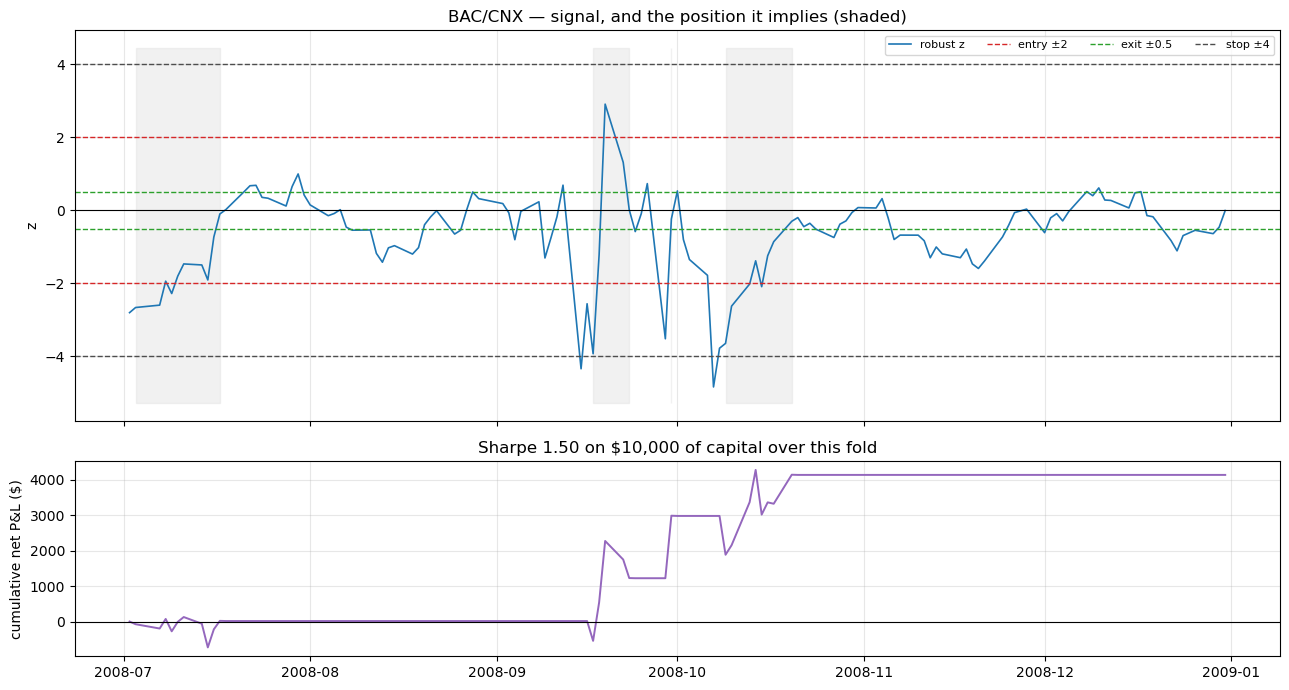

In [7]:
# 2) the z-score that produced them, with the entry/exit/stop bands, and 3) the equity curve
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(sig.index, sig["z"], lw=1.2, color="tab:blue", label="robust z")
for lv, c, lab in ((Z_ENTRY, "tab:red", "entry ±2"), (Z_EXIT, "tab:green", "exit ±0.5"),
                   (Z_STOP, "0.3", "stop ±4")):
    ax[0].axhline(lv, color=c, ls="--", lw=1, label=lab); ax[0].axhline(-lv, color=c, ls="--", lw=1)
ax[0].axhline(0, color="k", lw=0.8)
inpos = sig["pos"].ne(0)
ax[0].fill_between(sig.index, ax[0].get_ylim()[0], ax[0].get_ylim()[1], where=inpos,
                   color="0.85", alpha=0.35, step="mid")
ax[0].set_ylabel("z"); ax[0].legend(ncol=4, fontsize=8)
ax[0].set_title(f"{t1}/{t2} — signal, and the position it implies (shaded)")

eq = daily["pnl_net"].cumsum()
ax[1].plot(eq.index, eq, lw=1.4, color="tab:purple")
ax[1].axhline(0, color="k", lw=0.8); ax[1].set_ylabel("cumulative net P&L ($)")
ax[1].set_title(f"Sharpe {summ['sharpe']:.2f} on ${CAP:,} of capital over this fold")
plt.tight_layout(); plt.show()

In [8]:
# 4) the performance summary, the same fields notebook 02 reports
keys = ["start", "end", "bars", "sharpe", "ann_return", "ann_vol", "max_drawdown_pct",
        "n_trades", "hit_rate", "avg_win", "avg_loss", "profit_factor", "avg_hold_bars",
        "gross_pnl", "net_pnl", "turnover_annualized"]
one = pd.Series({k: summ[k] for k in keys if k in summ}, name=f"{t1}/{t2}")
display(one.to_frame())
if len(trades):
    print("\nround trips:")
    display(trades[["entry", "exit", "side", "bars", "pnl_gross", "cost", "pnl_net"]].round(2))

,BAC/CNX
start,2008-07-02 00:00:00
end,2008-12-31 00:00:00
bars,127
sharpe,1.500718
ann_return,0.966958
ann_vol,0.547421
max_drawdown_pct,0.088327
n_trades,4
hit_rate,1.0
avg_win,1040.335285



round trips:


,entry,exit,side,bars,pnl_gross,cost,pnl_net
0,2008-07-03,2008-07-18,1,10,25.59,6.27,19.31
1,2008-09-17,2008-09-24,1,5,1220.23,6.74,1213.49
2,2008-09-30,2008-10-01,1,1,1770.78,5.89,1764.90
3,2008-10-09,2008-10-21,1,8,1170.71,7.07,1163.64


This is one fold of one pair, and the best one of the 287 — it is the *shape* that is worth reading, not
the number. Four things in it generalise, and the last one is uncomfortable.

**The position is on for a small fraction of the window.** The shaded spans are where the rule holds
anything; most of the fold is flat. That is what a Sharpe computed on deployed capital means in §3, and
why the portfolio holds fewer than ten pairs on average out of twenty selected.

**The z-score is a formation-window object.** Its look-back and its warm-up history both come from before
the trading window opens, so the bands the signal crosses were fixed before any of these bars were seen.
That is the whole reason this is an out-of-fold result rather than a fitted one.

**The round-trip table reconciles with the ledger only up to a known defect.** The `cost` column here
omits each trade's closing print — see the note in the README's gotchas — so the trade-level P&L is
slightly flattering while the equity curve above, and every Sharpe in this notebook, is computed from the
daily ledger and is unaffected.

**Look at the names in the contributor table.** TVIX, UVXY, FAZ, LABU, DUST — these are not equities.
They are daily-rebalanced leveraged, inverse and volatility products, and the count above says
**112 of the 287 pair-folds (39%) involve one, contributing 39% of the rule's P&L**. Seventeen distinct
such tickers were selected across the twenty years.

This is a gap in the universe screen, not in the statistics. Notebook 07's liquidity gates ask for price,
dollar volume, coverage and a volatility *floor*; a 3× inverse ETF clears every one of them comfortably —
it is liquid, expensive enough, and extremely volatile. Nothing in the screen asks what the instrument
*is*. The volatility floor was added to keep money-market funds out of the screen; the same reasoning
should keep leveraged products out, and does not.

Two honest qualifications, in both directions. Their P&L share (39%) is almost exactly their count share
(39%), so the edge is **not** concentrated in them — strip them out and the result scales down rather
than collapsing. But a cointegration test on a product with deterministic decay and a daily reset is
testing something other than a common stochastic trend, and most practitioners would not trade these as
pairs at all. Read the headline **+0.40** as a number produced on a universe that includes them, and treat
an equities-only rerun as unfinished work rather than a formality.

## 4. Does the hedge matter, and do dividends?

Two one-line variations on the best rule: a Kalman hedge in place of the frozen regression, and the same
backtest with the dividend cash flow switched off. The second is not a strategy choice — it is the size
of the error a backtest makes when it ignores that a short leg pays its dividends.

In [9]:
best = max(runs.values(), key=lambda r: r["sharpe"])["rule"]
print("rule carried forward:", best)
variants = [runs[best],
            backtest(best, hedge="kalman"),
            backtest(best, with_dividends=False)]
labels = ["static hedge, dividends accrued", "Kalman hedge, dividends accrued", "static hedge, dividends ignored"]
vt = pd.DataFrame([row(r) for r in variants]).set_index("")
vt.index = labels
display(vt.round(3))
print(f"ignoring dividends changes twenty-year P&L by "
      f"${(variants[2]['total_pnl'] - variants[0]['total_pnl']) / 1e3:+,.1f}k "
      f"and Sharpe by {variants[2]['sharpe'] - variants[0]['sharpe']:+.2f}")

rule carried forward: bh_dual


,Sharpe,± s.e.,return on capital,P&L ($k),costs ($k),dividends ($k),max DD ($k),pair-folds,trades,avg pairs live
"static hedge, dividends accrued",0.402,0.262,0.022,43.587,8.495,0.483,-11.082,287,723,9.619
"Kalman hedge, dividends accrued",0.276,0.262,0.016,18.463,18.303,-0.849,-15.633,287,1707,9.619
"static hedge, dividends ignored",0.395,0.262,0.022,43.104,8.495,0.000,-11.082,287,723,9.619


ignoring dividends changes twenty-year P&L by $-0.5k and Sharpe by -0.01


The frozen per-fold regression beats the Kalman hedge, 0.40 against 0.28, and the mechanism is the one
notebook 12 found on minute bars: the filter re-estimates the hedge faster than the spread reverts, so it
absorbs part of the signal into its state and trades more than twice as often (1,707 round trips against
723) for less money. On daily bars the effect is milder than intraday, but it points the same way.

Dividends turn out to be second-order here, which is worth knowing precisely because it is not obvious.
Accruing them changes the twenty-year P&L by \$0.5k and the Sharpe by 0.01. The reason is structural: the
book is dollar-neutral, so the dividend received on the long leg is largely paid away on the short one,
and only the difference in yield survives. The look-ahead in `close_tr` that notebook 07 removed was
never mainly about the cash — it was about the prices the signal is computed from.

## 5. Costs

Five basis points per leg per side is a reasonable retail-to-institutional figure for liquid US equities
on daily closes. Sweeping it from zero says how much of the result is edge and how much is the cost
assumption.

,bh_dual,raw_dual_top20,distance_top20
cost (bps per leg-side),,,
0.0,0.537,0.181,0.167
2.5,0.470,0.110,-0.123
5.0,0.402,0.040,-0.412
7.5,0.334,-0.030,-0.701
10.0,0.266,-0.101,-0.989
15.0,0.131,-0.241,-1.559


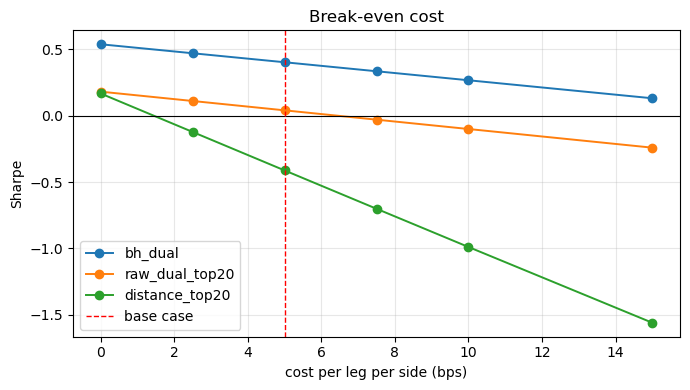

In [10]:
COSTS = [0.0, 2.5, 5.0, 7.5, 10.0, 15.0]
sweep = pd.DataFrame([{**{"cost (bps per leg-side)": c},
                       **{n: backtest(n, cost_bps=c)["sharpe"] for n in RULES}} for c in COSTS]).set_index("cost (bps per leg-side)")
display(sweep.round(3))
fig, ax = plt.subplots(figsize=(7, 4))
for n in RULES:
    ax.plot(sweep.index, sweep[n], marker="o", lw=1.4, label=n)
ax.axhline(0, color="k", lw=0.8); ax.axvline(COST_BPS, color="r", ls="--", lw=1, label="base case")
ax.set_xlabel("cost per leg per side (bps)"); ax.set_ylabel("Sharpe"); ax.legend(); ax.set_title("Break-even cost")
plt.tight_layout(); plt.show()

At zero cost every rule is positive; at 5 bps the distance rule is well under water and the raw-$p$ rule
is all but (0.04). That is the clearest statement of how thin this is: costs consume about a quarter of
the BH rule's gross Sharpe (0.54 to 0.40), four-fifths of the raw-$p$ rule's (0.18 to 0.04), and rather
more than all of the distance rule's (0.17 to −0.41). The BH rule stays above water out to roughly 15 bps per leg per side, which is
a comfortable margin against the 1–3 bps that liquid US equities actually cost on daily closes — but the
margin is on a number that is not statistically distinguishable from zero to begin with.

## 6. When did it work?

Pairs trading is documented to have decayed after the mid-2000s as the trade became crowded. Twenty years
of folds is enough to look. The rolling three-year Sharpe and the year-by-year table below are computed
on the same P&L series as §3.

,2006,2008,2009,2010,2011,2012,2013,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
P&L ($k),-0.33,4.07,-0.31,0.21,1.70,-0.10,3.48,1.00,0.58,-0.04,5.18,3.57,-0.08,-0.13,22.74,-1.11,-1.21,4.38
Sharpe,-0.09,1.40,-0.14,-0.38,0.15,-3.13,0.36,0.58,0.66,-3.45,0.47,1.65,-1.39,-0.15,1.85,-0.33,-0.49,1.35
pairs live (avg),20.00,3.00,5.00,16.03,19.93,1.00,10.58,4.00,3.00,1.00,20.00,19.00,1.00,2.00,11.97,9.50,10.93,12.63


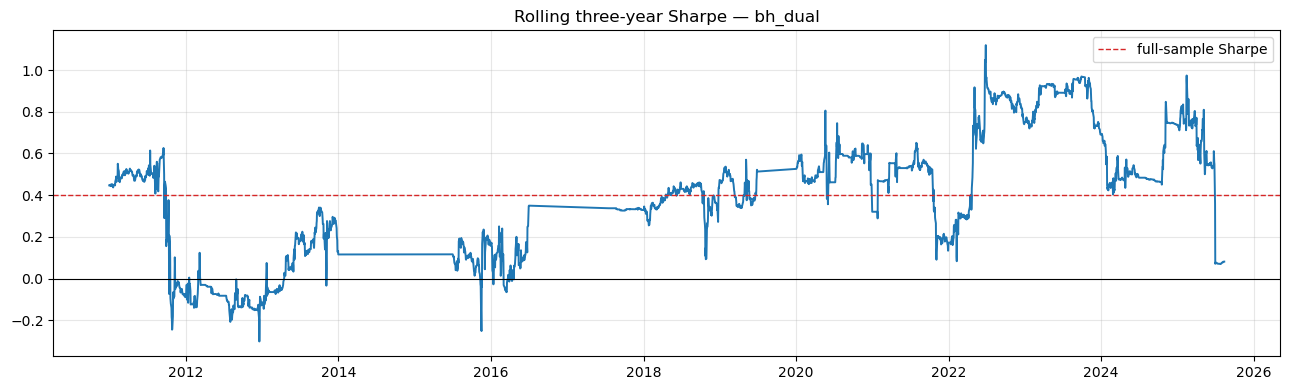

2006–2015 Sharpe 0.35 (s.e. 0.39) | 2016–2025 Sharpe 0.52 (s.e. 0.35)


In [11]:
r = runs[best]
by_year = r["pnl"]["pnl"].groupby(r["pnl"].index.year).sum() / 1e3
yr_ret = r["ret"].groupby(r["ret"].index.year)
yr = pd.DataFrame({"P&L ($k)": by_year,
                   "Sharpe": yr_ret.apply(lambda x: x.mean() / x.std(ddof=0) * np.sqrt(252) if x.std(ddof=0) > 0 else np.nan),
                   "pairs live (avg)": r["active"].groupby(r["active"].index.year).mean()})
display(yr.round(2).T)

roll = r["ret"].rolling(756)
roll_sharpe = roll.mean() / roll.std(ddof=0) * np.sqrt(252)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_sharpe.index, roll_sharpe, lw=1.4)
ax.axhline(0, color="k", lw=0.8); ax.axhline(r["sharpe"], color="tab:red", ls="--", lw=1, label="full-sample Sharpe")
ax.set_title(f"Rolling three-year Sharpe — {best}"); ax.legend(); plt.tight_layout(); plt.show()
first, second = r["ret"][r["ret"].index < "2016-01-01"], r["ret"][r["ret"].index >= "2016-01-01"]
sh = lambda x: x.mean() / x.std(ddof=0) * np.sqrt(252)
print(f"2006–2015 Sharpe {sh(first):.2f} (s.e. {np.sqrt(252/len(first)):.2f}) | "
      f"2016–2025 Sharpe {sh(second):.2f} (s.e. {np.sqrt(252/len(second)):.2f})")

The P&L is not a stream, it is three years. **2022 alone contributed \$22.7k of the \$43.6k total**, with
2018 (\$5.2k), 2025 (\$4.4k) and 2008 (\$4.1k) most of the rest; eight of the eighteen years that carry a
position at all are negative.
A strategy whose twenty-year record is more than half one year is not one that a Sharpe ratio describes
well, and the rolling three-year line makes the same point — long flat stretches punctuated by short
bursts, which is what a convergence trade looks like when convergence is rare.

There is no sign of the decay the literature reports for the classical distance method: the second half
of the sample (0.52) is nominally better than the first (0.35), and the two are well inside each other's
standard errors. What the year-by-year table does show is that the number of live pairs swings between one
and twenty, because the screen simply finds nothing in most periods. The strategy is not being turned off
by crowding; it is being turned off by the absence of candidates.

## 7. What the survivorship bias was worth

Notebook 07 measured the bias in a buy-and-hold universe. Here it is measured where it actually matters:
the same backtest, same rules, same costs, with the universe restricted to **today's** index members —
the assumption behind notebooks 01–05.

Note that this understates the effect, because the selection came from a screen already run on the
point-in-time universe. It is the cheap half of the bias, and it is still visible.

,point-in-time Sharpe,today's members Sharpe,point-in-time P&L ($k),today's members P&L ($k),pair-folds kept
rule,,,,,
bh_dual,0.402,0.420,43.587,17.841,44/287
raw_dual_top20,0.040,-0.044,5.650,-0.609,192/779
distance_top20,-0.412,0.230,-12.563,-1.140,88/780


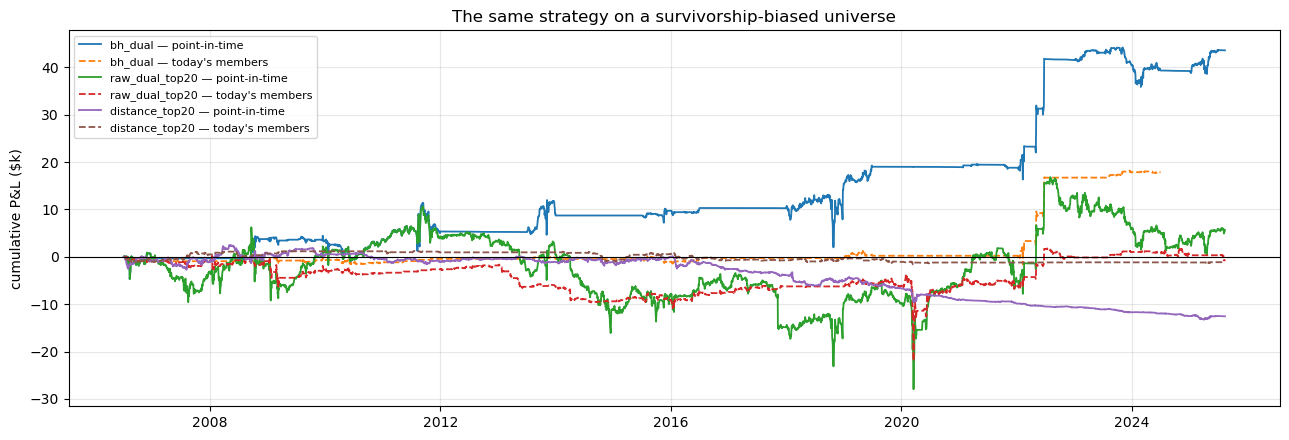

In [12]:
members = set(load_universe("spx_ndx_combined"))
in_members = lambda pair, d: pair[0] in members and pair[1] in members
surv = {name: backtest(name, universe_filter=in_members) for name in RULES}
cmp_rows = []
for name in RULES:
    a, b = runs[name], surv[name]
    cmp_rows.append({"rule": name, "point-in-time Sharpe": a["sharpe"], "today's members Sharpe": b["sharpe"] if b else np.nan,
                     "point-in-time P&L ($k)": a["total_pnl"] / 1e3, "today's members P&L ($k)": b["total_pnl"] / 1e3 if b else np.nan,
                     "pair-folds kept": f"{b['n_pairs'] if b else 0}/{a['n_pairs']}"})
display(pd.DataFrame(cmp_rows).set_index("rule").round(3))
fig, ax = plt.subplots(figsize=(13, 4.5))
for name in RULES:
    ax.plot(runs[name]["equity"].index, runs[name]["equity"] / 1e3, lw=1.3, label=f"{name} — point-in-time")
    if surv[name]:
        ax.plot(surv[name]["equity"].index, surv[name]["equity"] / 1e3, lw=1.3, ls="--",
                label=f"{name} — today's members")
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("cumulative P&L ($k)")
ax.set_title("The same strategy on a survivorship-biased universe"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The effect is large, and it is not uniform. Restricting to today's index members throws away 85% of the
BH rule's pair-folds (44 of 287) and 60% of its P&L, while leaving the Sharpe almost unchanged — the
surviving names were not where the money came from. The distance rule is the striking case: its Sharpe goes from
−0.41 on the point-in-time universe to +0.23 on the survivors. It still loses money in dollars either way
(−\$12.6k against −\$1.1k), so what the restriction flips is the sign of the ratio, not of the P&L.
Selecting pairs by co-movement and then only trading the ones that are still in the index twenty years
later is close to a definition of survivorship bias, and it is enough to turn a visibly losing rule into
one that looks respectable.

As flagged above, this understates the full effect, because the candidate pairs were still chosen by a
screen run on the point-in-time universe. A study that had screened today's members from the start — the
design of notebooks 01–05 — would compound the two.

## 8. Honest assessment

**What twenty years of properly-constructed data say.** Cointegration among liquid US equities is real but
rare. Against a uniform null, 7.2% of 1.74 million tests reject at 5% where 5% is expected, and Storey's
estimator puts 93% of pairs in the null. Under FDR control the median formation yields three tradeable
pairs out of 44,850 tested, and nine of thirty-nine yield none. Trading what survives returns **+0.40
Sharpe (± 0.26) and 2.2% on deployed capital over 2006–2025**, with more than half the P&L from 2022 and
fewer than ten pairs live on average — though the yearly average runs from 1 to 20.

**The one thing that is clearly established** is the value of the multiple-testing correction. The three
selection rules order themselves exactly as the statistics say they should — BH +0.40, raw $p$ +0.04,
distance −0.41 — and the gap between the first and the last is several standard errors even though none
of them is individually far from zero. The Benjamini–Hochberg default that this repository has carried
since the beginning now has twenty years of evidence behind it rather than one pair over five years.

**What is not established** is that the strategy is worth running. A Sharpe 1.5 standard errors from zero,
earned almost entirely in three of nineteen years, on a book that can deploy about \$100k, is a research
finding rather than an allocation. Scaling it would require a wider universe — the day lake's market
layout holds every listed symbol, and this study used the 300 most traded — and that would multiply the
number of tests, which under FDR control makes discoveries harder, not easier.

**What was worth fixing, in order of how much it mattered.** Survivorship bias came first: holding today's
index members instead of what was tradeable is worth +6.1% a year on a plain equal-weight portfolio
(notebook 07), and it flips the sign of the distance rule here. The data-quality gates came second —
without them a NASDAQ test symbol, tickers shared by different companies, and the split-adjustment price
trap put Sirius XM at the top of the 2008 screen. Dividend accounting came last, and on a dollar-neutral
book it is worth 0.01 of Sharpe.

**Caveats.** Costs are a flat 5 bps per leg-side rather than measured spreads; entries and exits are at
the close with no slippage model; there is no earnings or corporate-event filter; the hedge is a frozen
regression refit twice a year; short availability and borrow rates are assumed constant at 50 bp/year;
and the universe is capped at the 300 most traded names, which is a compute decision rather than an
economic one.